__SOLAR ACTIVITY AND ENERGY DEMAND DATA ANALYSIS__

CAN ARTIFICIAL INTELLIGENCE MODELS PREDICT CHANGES IN ENERGY DEMAND BASED ON SOLAR ACTIVITY?

In [2]:
#Solar Storm and Energy Analysis project
import pandas as pd

energy_data_path = "psco_data.txt"
omni_data_path = "omni_raw.lst"

Initialize data frames with Pandas

In [3]:
#Energy data in Colorado
edf = pd.read_csv(energy_data_path, sep = "\t", engine = "python")
edf.head(20)

,BA,UTC time,Local date,Hour,Local time,Time zone,Generation only?,Demand forecast,Demand,Net generation,...,CO2 Emissions: OIL,CO2 Emissions: Other,CO2 Emissions Generated,CO2 Emissions Imported,CO2 Emissions Exported,CO2 Emissions Consumed,Positive Generation,Consumed Electricity,CO2 Emissions Intensity for Generated Electricity,CO2 Emissions Intensity for Consumed Electricity
0,PSCO,01Jul2015 7:00:00,01Jul2015,1,01Jul2015 1:00:00,Mountain,N,"4,618","4,875","4,119",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PSCO,01Jul2015 8:00:00,01Jul2015,2,01Jul2015 2:00:00,Mountain,N,"4,337","4,618","3,886",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PSCO,01Jul2015 9:00:00,01Jul2015,3,01Jul2015 3:00:00,Mountain,N,"4,163","4,427","3,874",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PSCO,01Jul2015 10:00:00,01Jul2015,4,01Jul2015 4:00:00,Mountain,N,"4,084","4,344","3,775",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PSCO,01Jul2015 11:00:00,01Jul2015,5,01Jul2015 5:00:00,Mountain,N,"4,105","4,374","3,768",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,PSCO,01Jul2015 12:00:00,01Jul2015,6,01Jul2015 6:00:00,Mountain,N,"4,271","4,505","3,963",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,PSCO,01Jul2015 13:00:00,01Jul2015,7,01Jul2015 7:00:00,Mountain,N,"4,564","4,811","4,188",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,PSCO,01Jul2015 14:00:00,01Jul2015,8,01Jul2015 8:00:00,Mountain,N,"4,932","5,224","4,583",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,PSCO,01Jul2015 15:00:00,01Jul2015,9,01Jul2015 9:00:00,Mountain,N,"5,263","5,640","5,039",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,PSCO,01Jul2015 16:00:00,01Jul2015,10,01Jul2015 10:00:00,Mountain,N,"5,589","6,088","5,361",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#OMNI solar weather data
colspecs = [
    (0, 4),   # YEAR
    (4, 8),   # DOY
    (8, 11),  # Hour
    (11, 17), # Scalar B
    (17, 23), # BX
    (23, 29), # BY
    (29, 35), # BZ
    (35, 44), # Temperature
    (44, 50), # Density
    (50, 56), # Speed
    (56, 62), # Flow pressure
    (62, 69), # Electric field
    (69, 72), # Kp
    (72, 78), # Dst
    (78, 83), # AE
]

names = [
    "year", "doy", "hour",
    "B_scalar", "Bx", "By", "Bz",
    "temp", "density", "speed",
    "pressure", "E_field",
    "Kp", "Dst", "AE"
]

sdf= pd.read_fwf(omni_data_path, colspecs=colspecs, names=names)
sdf.head(20)

,year,doy,hour,B_scalar,Bx,By,Bz,temp,density,speed,pressure,E_field,Kp,Dst,AE
0,1973,1,0,999.9,999.9,999.9,999.9,9999999.0,999.9,9999.0,99.99,999.99,40,-9,226
1,1973,1,1,4.3,2.7,0.6,-0.2,9999999.0,999.9,9999.0,99.99,999.99,40,-6,182
2,1973,1,2,4.8,0.9,-3.8,-1.8,141884.0,6.3,511.0,3.22,0.92,40,-6,138
3,1973,1,3,5.7,1.8,-3.5,-1.6,159281.0,7.0,502.0,3.52,0.80,33,-8,90
4,1973,1,4,6.2,0.9,-2.6,-3.1,166532.0,7.2,516.0,3.84,1.60,33,-15,189
5,1973,1,5,5.5,1.9,-1.2,2.9,172556.0,5.2,535.0,2.94,-1.55,33,-13,205
6,1973,1,6,5.5,3.3,-1.6,2.8,170765.0,4.5,536.0,2.66,-1.50,23,-13,73
7,1973,1,7,4.6,2.4,-2.6,0.4,173659.0,4.3,530.0,2.41,-0.21,23,-13,100
8,1973,1,8,4.0,2.5,-0.5,1.0,152720.0,4.5,536.0,2.57,-0.54,23,-15,138
9,1973,1,9,4.0,3.1,0.1,-0.5,144948.0,4.4,527.0,2.42,0.26,33,-13,264


In [5]:
#Convert year, doy, and hour to datetime
sdf['datetime'] = pd.to_datetime(sdf['year'], format='%Y') + \
                  pd.to_timedelta(sdf['doy'] - 1, unit='D') + \
                  pd.to_timedelta(sdf['hour'], unit='h')

sdf = sdf.set_index('datetime')

edf['UTC time'] = pd.to_datetime(edf['UTC time'])
edf = edf.set_index('UTC time')


In [6]:
#Featuring for random forest model - extract time-based features
edf['hour'] = edf.index.hour
edf['day_of_week'] = edf.index.dayofweek
edf['month'] = edf.index.month
edf['is_weekend'] = edf['day_of_week'].isin([5, 6]).astype(int)


In [7]:
#Join datasets on datetime index
sdf = sdf.drop(columns=['hour'])
df = edf.join(sdf, how='inner')
df.head()


,BA,Local date,Hour,Local time,Time zone,Generation only?,Demand forecast,Demand,Net generation,Total interchange,...,By,Bz,temp,density,speed,pressure,E_field,Kp,Dst,AE
2015-07-01 07:00:00,PSCO,01Jul2015,1,01Jul2015 1:00:00,Mountain,N,"4,618","4,875","4,119",-756,...,5.0,1.6,45556.0,7.5,368.0,1.98,-0.52,7,-13,95
2015-07-01 08:00:00,PSCO,01Jul2015,2,01Jul2015 2:00:00,Mountain,N,"4,337","4,618","3,886",-732,...,2.9,1.4,62276.0,6.2,369.0,1.67,-0.48,7,-13,64
2015-07-01 09:00:00,PSCO,01Jul2015,3,01Jul2015 3:00:00,Mountain,N,"4,163","4,427","3,874",-553,...,2.1,1.1,74872.0,6.4,382.0,1.89,-0.38,13,-10,58
2015-07-01 10:00:00,PSCO,01Jul2015,4,01Jul2015 4:00:00,Mountain,N,"4,084","4,344","3,775",-569,...,1.4,-1.1,87840.0,6.0,381.0,1.77,0.46,13,-11,72
2015-07-01 11:00:00,PSCO,01Jul2015,5,01Jul2015 5:00:00,Mountain,N,"4,105","4,374","3,768",-606,...,0.9,-0.2,102864.0,5.0,395.0,1.60,0.04,13,-15,71


In [8]:
#Fill missing values in demand 
df['Demand'] = df['Demand'].fillna(method='ffill')
len(df), df.columns, df['Demand'].isna().sum()

C:\Users\tjsim\AppData\Local\Temp\ipykernel_23300\856648192.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Demand'] = df['Demand'].fillna(method='ffill')


(92321,
 Index(['BA', 'Local date', 'Hour', 'Local time', 'Time zone',
        'Generation only?', 'Demand forecast', 'Demand', 'Net generation',
        'Total interchange',
        ...
        'By', 'Bz', 'temp', 'density', 'speed', 'pressure', 'E_field', 'Kp',
        'Dst', 'AE'],
       dtype='object', length=101),
 np.int64(0))

In [9]:
# Remove commas from all string columns, then convert to numbers if possible
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '', regex=False)

# Convert everything that can be numeric into numeric
df = df.apply(pd.to_numeric, errors='ignore')


C:\Users\tjsim\AppData\Local\Temp\ipykernel_23300\4075293472.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [10]:
#Baseline random forest model using only time-based features
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Baseline features (time only)
features = ['hour', 'day_of_week', 'month', 'is_weekend']
target = 'Demand'

X = df[features]
y = df[target]

# Train/test split (no shuffle to preserve time order)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print("Baseline MAE:", mae)


Baseline MAE: 356.39402439083847


In [11]:
# Time + solar features
features_with_solar = [
    'hour', 'day_of_week', 'month', 'is_weekend',
    'Bz', 'Kp', 'speed', 'density'
]

target = 'Demand'

X = df[features_with_solar]
y = df[target]

# Drop rows with missing values in these columns
X = X.dropna()
y = y.loc[X.index]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model
model_solar = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model_solar.fit(X_train, y_train)

# Evaluate
preds_solar = model_solar.predict(X_test)
mae_solar = mean_absolute_error(y_test, preds_solar)

print("Solar model MAE:", mae_solar)


Solar model MAE: 403.12833820741946


In [12]:
#Define solar features
features_all_solar = [
    'hour', 'day_of_week', 'month', 'is_weekend',
    'B_scalar', 'Bx', 'By', 'Bz',
    'temp', 'density', 'speed', 'pressure',
    'E_field', 'Kp', 'Dst', 'AE'
]


In [ ]:
target = 'Demand'

X = df[features_all_solar]
y = df[target]

# Drop rows with missing values in these columns
X = X.dropna()
y = y.loc[X.index]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train model
model_all_solar = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model_all_solar.fit(X_train, y_train)

# Evaluate
preds_all_solar = model_all_solar.predict(X_test)
mae_all_solar = mean_absolute_error(y_test, preds_all_solar)

print("All-solar model MAE:", mae_all_solar)


All-solar model MAE: 403.3341429731925


Standardizing demand and Kp and checking if there is any overlap in clear outliers

In [15]:
import numpy as np

df['demand_z'] = (df['Demand'] - df['Demand'].mean()) / df['Demand'].std()
df['energy_anomaly'] = (np.abs(df['demand_z']) > 3).astype(int)
df['energy_anomaly'].sum()


np.int64(1244)

In [16]:
df['Kp_z'] = (df['Kp'] - df['Kp'].mean()) / df['Kp'].std()
df['solar_anomaly'] = (df['Kp_z'] > 3).astype(int)
df['solar_anomaly'].sum()


np.int64(942)

In [17]:
overlap = df[(df['energy_anomaly'] == 1) & (df['solar_anomaly'] == 1)]
len(overlap)

19

In [18]:
#Printing overlap to see if there is any significance
overlap_events = df[(df['energy_anomaly'] == 1) & (df['solar_anomaly'] == 1)]
overlap_events[['Demand', 'Kp', 'Bz', 'speed', 'density']].head(20)


,Demand,Kp,Bz,speed,density
2023-02-27 08:00:00,169,67,-10.7,9999.0,999.9
2023-02-27 09:00:00,225,67,-9.2,9999.0,999.9
2023-02-27 10:00:00,262,67,-10.2,9999.0,999.9
2023-02-27 11:00:00,228,67,-12.9,771.0,5.8
2023-02-27 12:00:00,266,63,-0.4,794.0,6.2
2023-02-27 13:00:00,342,63,6.6,846.0,7.1
2023-02-27 14:00:00,299,63,6.4,824.0,7.6
2023-02-27 15:00:00,389,67,-6.0,824.0,6.9
2023-02-27 16:00:00,291,67,-6.1,801.0,8.1
2023-02-27 17:00:00,252,67,-6.9,788.0,5.6


Since the model cannot find a correlation between solar storms and energy demand instantaneously, doing graphical analysis to see if there really is a correlation or a pattern to be found, wether it be due to lag or something else

<Axes: >

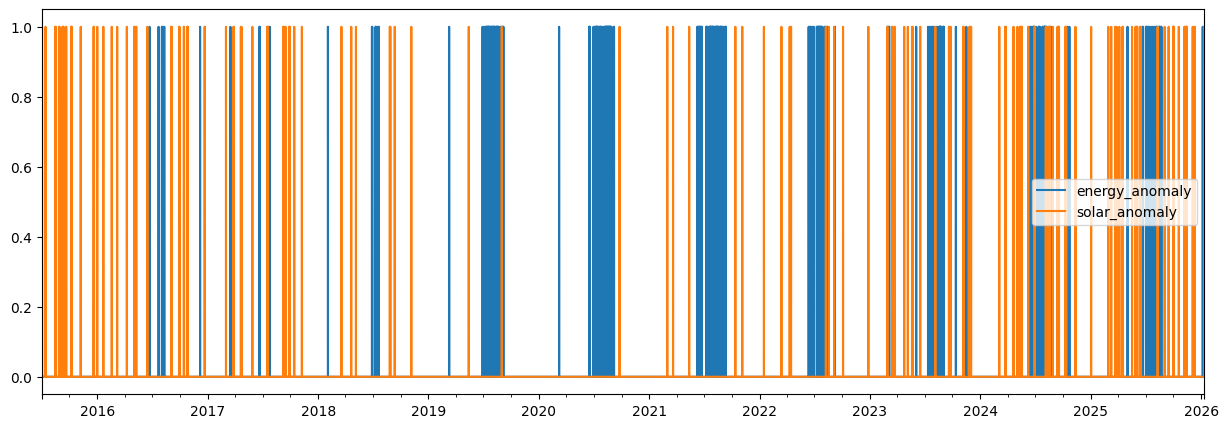

In [19]:
df[['energy_anomaly', 'solar_anomaly']].plot(figsize=(15,5))
#Graphing current anomalies to see the relationship


Clipping data to 2021 and on, as it seems there may be a pattern there, and I expect that there was a technological advancement that helps us more accurately determine anomalies. There also appears to be more consistent data

In [20]:
df_2021 = df[df.index >= "2021-01-01"].copy()
len(df_2021)


44064

In [21]:
#Calculating anomalies for 2021 subset based on z score
df_2021['demand_z'] = (df_2021['Demand'] - df_2021['Demand'].mean()) / df_2021['Demand'].std()
df_2021['energy_anomaly'] = (df_2021['demand_z'].abs() > 3).astype(int)

df_2021['Kp_z'] = (df_2021['Kp'] - df_2021['Kp'].mean()) / df_2021['Kp'].std()
df_2021['solar_anomaly'] = (df_2021['Kp_z'] > 3).astype(int)

In [22]:
df_2021 = df[df.index >= "2021-01-01"].copy()
df_2021['solar_anomaly'].sum(), df_2021['energy_anomaly'].sum()


(np.int64(612), np.int64(780))

Trying to calculate an average delay from current anomaly lists

In [23]:
#Get timestamps of anomalies
solar_times = df_2021.index[df_2021['solar_anomaly'] == 1]
energy_times = df_2021.index[df_2021['energy_anomaly'] == 1]

delays = []

for t in solar_times:
    #Find energy anomalies after this solar anomaly
    future_energy = energy_times[energy_times > t]
    if len(future_energy) > 0:
        delay_hours = (future_energy[0] - t).total_seconds() / 3600
        delays.append(delay_hours)

print("Number of measured delays:", len(delays))
#print mean and standard deviation of delays
print("Mean delay (hours):", np.mean(delays))
print("Standard deviation of delay (hours):", np.std(delays))


Number of measured delays: 606
Mean delay (hours): 1124.546204620462
Standard deviation of delay (hours): 1260.5739840712556


As the standard deviation is extremely high, an "anomaly" will be redefined, based on what is seen in the graphs

In [24]:
df_2021.columns


Index(['BA', 'Local date', 'Hour', 'Local time', 'Time zone',
       'Generation only?', 'Demand forecast', 'Demand', 'Net generation',
       'Total interchange',
       ...
       'speed', 'pressure', 'E_field', 'Kp', 'Dst', 'AE', 'demand_z',
       'energy_anomaly', 'Kp_z', 'solar_anomaly'],
      dtype='object', length=105)

In [25]:
solar_vars = ['B_scalar', 'Bx', 'By', 'Bz', 'temp', 'density', 'speed',
              'pressure', 'E_field', 'Kp', 'Dst', 'AE']

#Standardize each solar variable
for col in solar_vars:
    df_2021[col + '_z'] = (df_2021[col] - df_2021[col].mean()) / df_2021[col].std()

In [26]:
solar_z = ['B_scalar_z', 'Bx_z', 'By_z', 'Bz_z', 'temp_z', 'density_z', 'speed_z',
           'pressure_z', 'E_field_z', 'Kp_z', 'Dst_z', 'AE_z']

#Build matrix of standardized solar data
Z = df_2021[solar_z].values

#Compute covariance matrix and its inverse
cov = np.cov(Z, rowvar=False)
cov_inv = np.linalg.inv(cov)

#Compute chi-square value for each row
chi_values = np.einsum('ij,jk,ik->i', Z, cov_inv, Z)

#Store in dataframe
df_2021['solar_chi'] = chi_values

df_2021['solar_chi'].head()

2021-01-01 00:00:00    3.072179
2021-01-01 01:00:00    2.950232
2021-01-01 02:00:00    2.945997
2021-01-01 03:00:00    2.347388
2021-01-01 04:00:00    2.430778
Name: solar_chi, dtype: float64

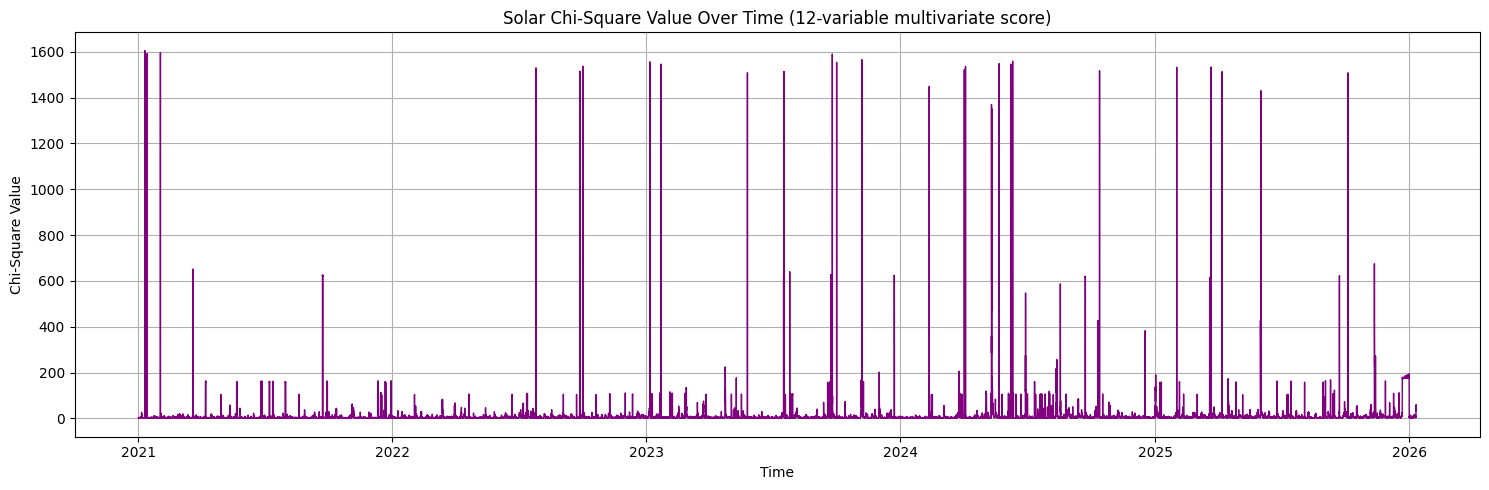

In [27]:
#graphing 
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df_2021.index, df_2021['solar_chi'], color='purple', linewidth=1)
plt.title("Solar Chi-Square Value Over Time (12-variable multivariate score)")
plt.xlabel("Time")
plt.ylabel("Chi-Square Value")
plt.grid(True)
plt.tight_layout()
plt.show()


The most clear outliers fall above the line of 400, so that will be the new definition of an "anomaly"

In [28]:
df_2021['solar_anomaly'] = (df_2021['solar_chi'] > 400).astype(int)

print("Number of solar anomalies:", df_2021['solar_anomaly'].sum())
#approximately 1.6% of the data is captured above 400


Number of solar anomalies: 138


In [29]:
#reusing demand z as new variables are not added
df_2021['demand_z']

2021-01-01 00:00:00    1.061870
2021-01-01 01:00:00    1.494913
2021-01-01 02:00:00    1.351582
2021-01-01 03:00:00    1.079151
2021-01-01 04:00:00    0.901257
                         ...   
2026-01-10 19:00:00    0.545470
2026-01-10 20:00:00    0.401122
2026-01-10 21:00:00    0.294386
2026-01-10 22:00:00    0.286254
2026-01-10 23:00:00    0.419420
Name: demand_z, Length: 44064, dtype: float64

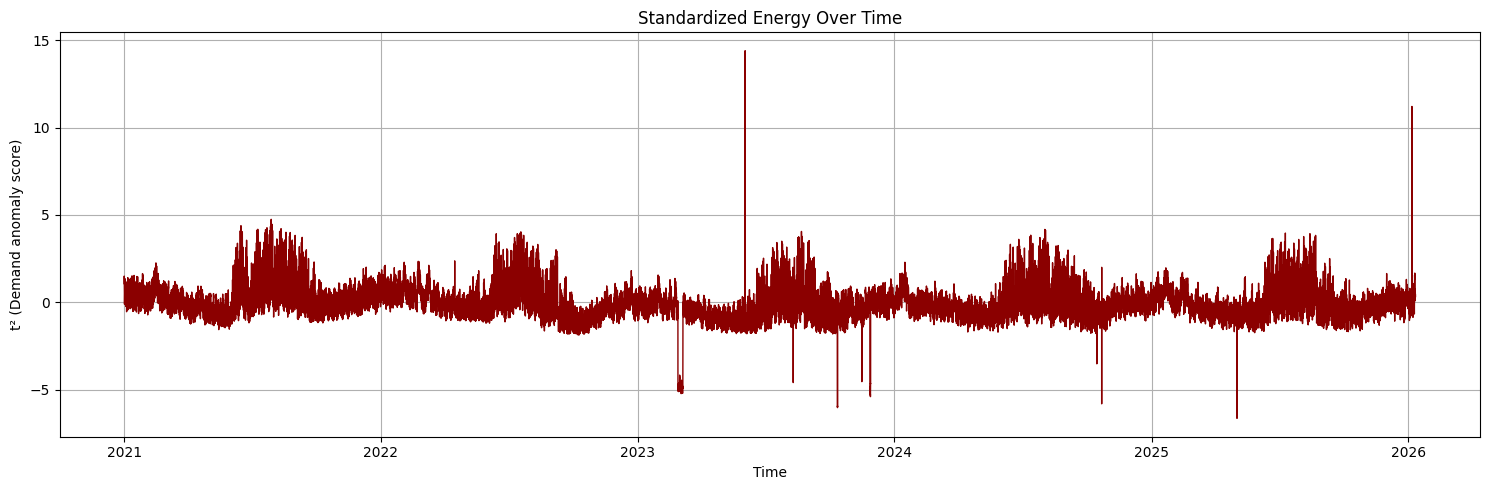

In [30]:
plt.figure(figsize=(15,5))
plt.plot(df_2021.index, df_2021['demand_z'], color='darkred', linewidth=1)
plt.title("Standardized Energy Over Time")
plt.xlabel("Time")
plt.ylabel("t² (Demand anomaly score)")
plt.grid(True)
plt.tight_layout()
plt.show()

It is clear that there are spikes in this graph, so the graphs will be overlaid onto each other for further analysis

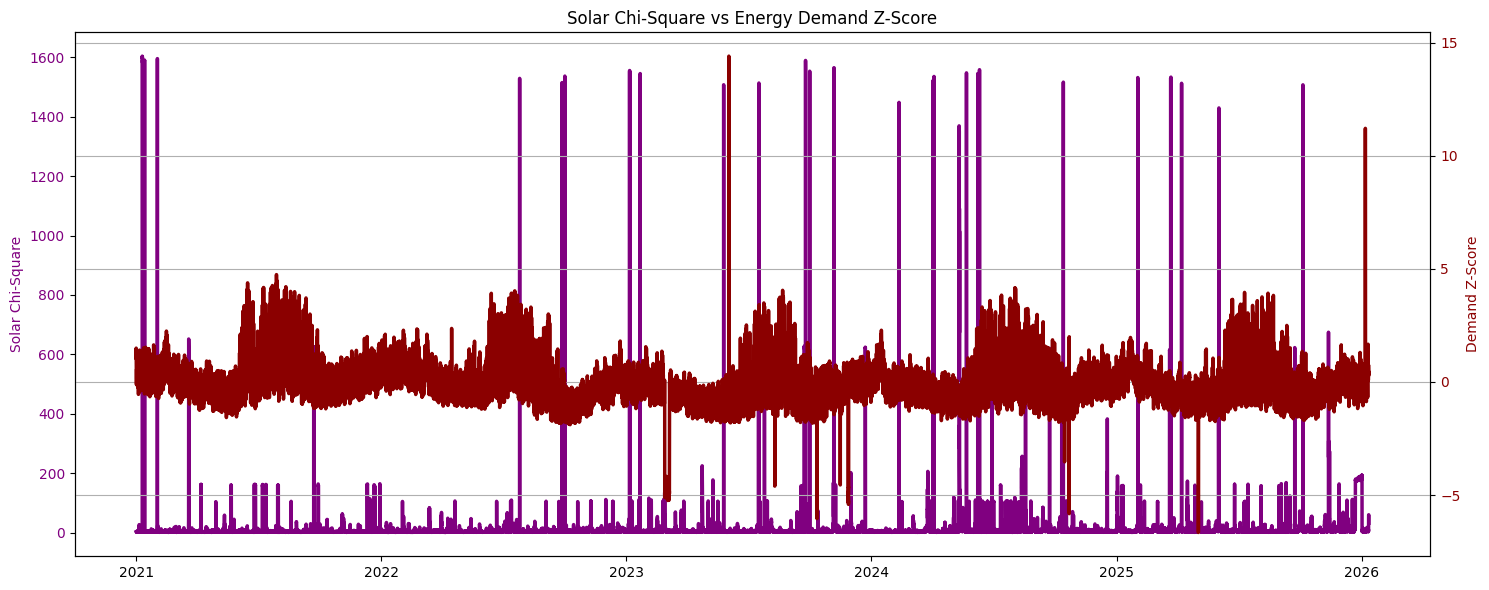

In [31]:
fig, ax1 = plt.subplots(figsize=(15,6))

# Energy demand z-score on right axis (thicker line)
ax2 = ax1.twinx()
ax2.plot(df_2021.index, df_2021['demand_z'], 
         color='darkred', label='Demand Z-Score', linewidth=2.5)
ax2.set_ylabel("Demand Z-Score", color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')
# Solar chi-square on left axis (thicker line)
ax1.plot(df_2021.index, df_2021['solar_chi'], 
         color='purple', label='Solar Chi-Square', linewidth=2.5)
ax1.set_ylabel("Solar Chi-Square", color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
plt.title("Solar Chi-Square vs Energy Demand Z-Score")
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
#perform a chi-square test for association to see if there really is an association between the standardized scores
from scipy.stats import chi2_contingency

max_lag = 24 * 90  # 3 month = 720 hours
p_values = []

for lag in range(max_lag + 1):
    # Shift energy anomalies forward by lag hours
    shifted_energy = df_2021['energy_anomaly'].shift(-lag)

    # Build contingency table
    contingency = pd.crosstab(df_2021['solar_anomaly'], shifted_energy)

    # Only run chi-square if table is 2x2
    if contingency.shape == (2, 2):
        chi2, p, dof, expected = chi2_contingency(contingency)
        p_values.append(p)
    else:
        p_values.append(np.nan)


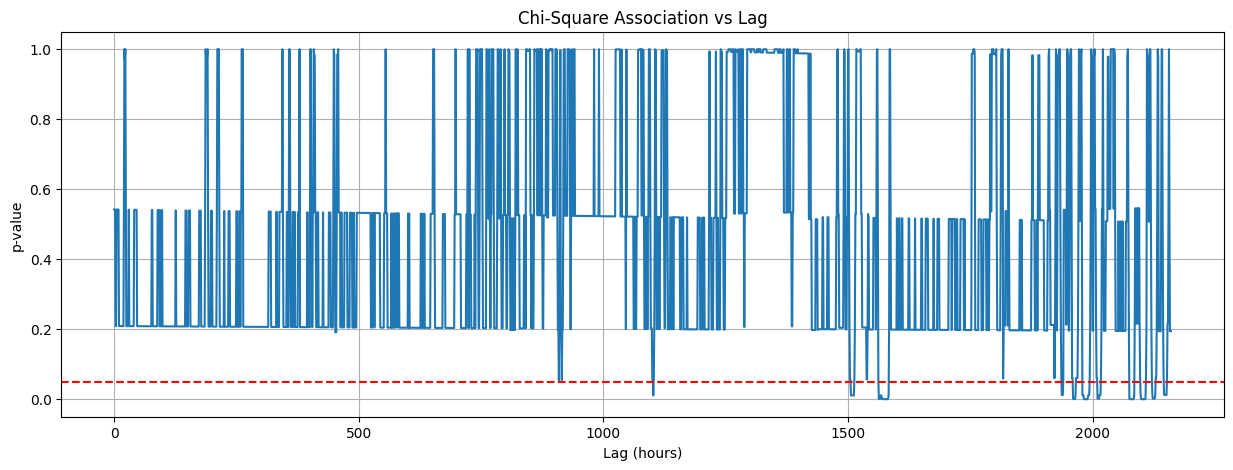

In [33]:
plt.figure(figsize=(15,5))
plt.plot(range(max_lag+1), p_values)
plt.axhline(0.05, color='red', linestyle='--')
plt.xlabel("Lag (hours)")
plt.ylabel("p-value")
plt.title("Chi-Square Association vs Lag")
plt.grid(True)
plt.show()


There are some significant delay hours. Here are the questions I have going forward:
1)  the solar anomalies close together can be classified as their own individual "storms" that may affect the data. Individual spikes may account for multiple data points0
2) does a delay of 2-3 months actually mean something?
3) how would solar weather actually affect energy demand?
After research, I have found that a delay of 2-3 months does not have significance, and therefore solar activity does not affect energy demand. However, analysis continues as I would like to find the answer to the next question:

DOES SOLAR ACTIVITY AFFECT POWER GRIDS

In [35]:
print(list(df_2021.columns))

['BA', 'Local date', 'Hour', 'Local time', 'Time zone', 'Generation only?', 'Demand forecast', 'Demand', 'Net generation', 'Total interchange', 'Imputed demand', 'Imputed net generation', 'Imputed total interchange', 'Adjusted demand', 'Adjusted net generation', 'Adjusted total interchange', 'NG: COL', 'NG: NG', 'NG: NUC', 'NG: OIL', 'NG: GEO', 'NG: WAT', 'NG: PS', 'NG: SUN', 'NG: SNB', 'NG: WND', 'NG: WNB', 'NG: BAT', 'NG: OES', 'NG: UES', 'NG: OTH', 'NG: UNK', 'Imputed COL Gen', 'Imputed NG Gen', 'Imputed NUC Gen', 'Imputed OIL Gen', 'Imputed GEO Gen', 'Imputed WAT Gen', 'Imputed PS Gen', 'Imputed SUN Gen', 'Imputed SNB Gen', 'Imputed WND Gen', 'Imputed WNB Gen', 'Imputed BAT Gen', 'Imputed OES Gen', 'Imputed UES Gen', 'Imputed OTH Gen', 'Imputed UNK Gen', 'Adjusted COL Gen', 'Adjusted NG Gen', 'Adjusted NUC Gen', 'Adjusted OIL Gen', 'Adjusted GEO Gen', 'Adjusted WAT Gen', 'Adjusted PS Gen', 'Adjusted SUN Gen', 'Adjusted SNB Gen', 'Adjusted WND Gen', 'Adjusted WNB Gen', 'Adjusted BAT

In [ ]:
#Trying net generation as representative of energy output to see if there is a relationship between solar anomalies and energy generation
df_2021['Net generation']


2021-01-01 00:00:00    5612.0
2021-01-01 01:00:00    6027.0
2021-01-01 02:00:00    5982.0
2021-01-01 03:00:00    5655.0
2021-01-01 04:00:00    5486.0
                        ...  
2026-01-10 19:00:00    5498.0
2026-01-10 20:00:00    5278.0
2026-01-10 21:00:00    5057.0
2026-01-10 22:00:00    5008.0
2026-01-10 23:00:00    5068.0
Name: Net generation, Length: 44064, dtype: float64

In [39]:
df_2021['gen_z'] = (
    df_2021['Net generation'] - df_2021['Net generation'].mean()
) / df_2021['Net generation'].std()
df_2021['gen_z']

2021-01-01 00:00:00    0.322966
2021-01-01 01:00:00    0.766251
2021-01-01 02:00:00    0.718184
2021-01-01 03:00:00    0.368896
2021-01-01 04:00:00    0.188378
                         ...   
2026-01-10 19:00:00    0.201196
2026-01-10 20:00:00   -0.033799
2026-01-10 21:00:00   -0.269861
2026-01-10 22:00:00   -0.322201
2026-01-10 23:00:00   -0.258112
Name: gen_z, Length: 44064, dtype: float64

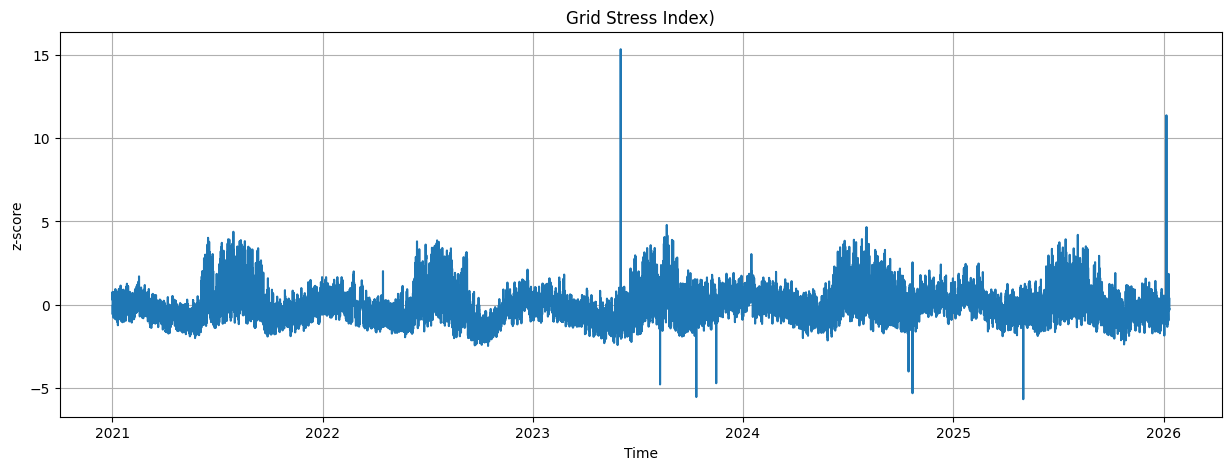

In [40]:
plt.figure(figsize=(15,5))
plt.plot(df_2021['gen_z'])
plt.title("Grid Stress Index)")
plt.xlabel("Time")
plt.ylabel("z-score")
plt.grid(True)
plt.show()


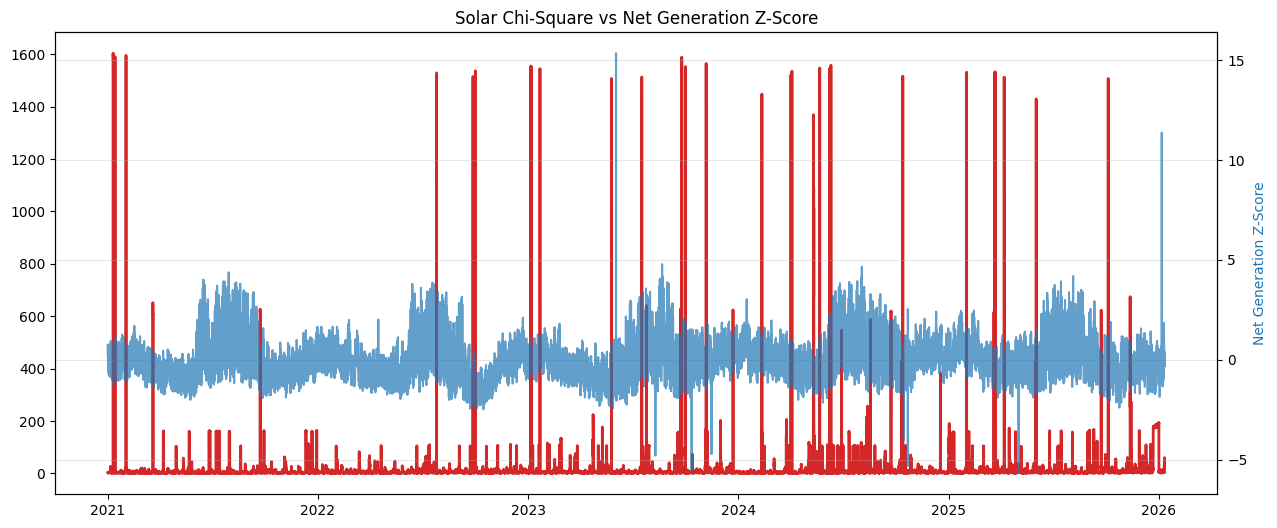

In [41]:
plt.figure(figsize=(15,6))

# Solar chi-square (left axis)
plt.plot(df_2021['solar_chi'], color='tab:red', label='Solar Chi-Square', linewidth=2)

# Create a second y-axis for generation z-scores
ax2 = plt.twinx()
ax2.plot(df_2021['gen_z'], color='tab:blue', label='Net Generation Z-Score', alpha=0.7)

# Labels and titles
plt.title("Solar Chi-Square vs Net Generation Z-Score")
plt.xlabel("Time")

# Left axis label
plt.ylabel("Solar Chi-Square", color='tab:red')

# Right axis label
ax2.set_ylabel("Net Generation Z-Score", color='tab:blue')

# Grid
plt.grid(True, alpha=0.3)

plt.show()


In [ ]:
#Trying random trees to see if we can predict net generation based on solar features


In [ ]:
df_2021['Net generation'].isna().sum()

np.int64(24)

In [48]:
df_clean = df_2021.dropna(subset=['Net generation'])
df_clean['Net generation'].isna().sum()

np.int64(0)

In [49]:
features = ['solar_chi', 'gen_z']
target = 'Net generation'

X = df_clean[features]
y = df_clean[target]

# -----------------------------------
# 2. Train/test split (no shuffle)
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# -----------------------------------
# 3. Train Random Forest model
# -----------------------------------
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------------
# 4. Predict + compute MAE
# -----------------------------------
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)

print("Random Forest MAE (Net Generation):", mae)

Random Forest MAE (Net Generation): 0.2938722373599844


In [ ]:
df_clean['grid_anomaly'] = (df_clean['gen_z'].abs() > 2).astype(int)

C:\Users\tjsim\AppData\Local\Temp\ipykernel_23300\687117394.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['grid_anomaly'] = (df_clean['gen_z'].abs() > 2).astype(int)


In [51]:
max_lag = 168  # 1 week
p_values = []

solar = df_clean['solar_anomaly'].values
grid = df_clean['grid_anomaly'].values

for lag in range(max_lag + 1):
    # Shift grid anomalies forward by 'lag' hours
    shifted_grid = np.roll(grid, lag)
    shifted_grid[:lag] = 0  # avoid wrap-around contamination

    # Build contingency table
    contingency = np.zeros((2, 2))

    for s, g in zip(solar, shifted_grid):
        contingency[int(s)][int(g)] += 1

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency)
    p_values.append(p)

# Store results
lags = np.arange(max_lag + 1)
df_lag = pd.DataFrame({'lag_hours': lags, 'p_value': p_values})


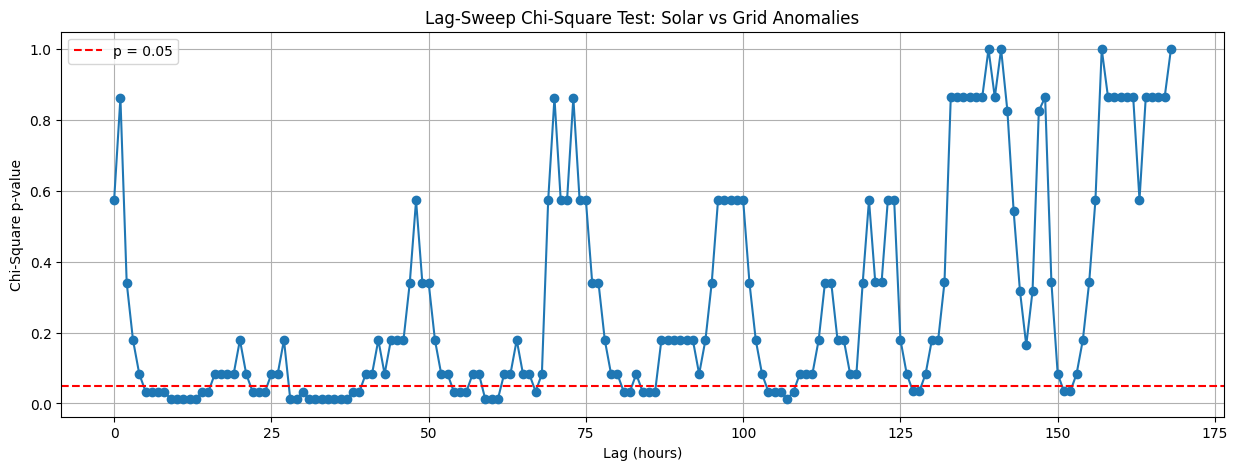

In [52]:
plt.figure(figsize=(15,5))
plt.plot(df_lag['lag_hours'], df_lag['p_value'], marker='o')
plt.axhline(0.05, color='red', linestyle='--', label='p = 0.05')
plt.xlabel("Lag (hours)")
plt.ylabel("Chi-Square p-value")
plt.title("Lag-Sweep Chi-Square Test: Solar vs Grid Anomalies")
plt.grid(True)
plt.legend()
plt.show()
